# Fraud Detection and Cost Optimization

This project simulates a real-world fraud detection system for online transactions, focusing on identifying fraudulent activity while minimizing disruption to legitimate users.

**Goal:** Build a model to detect fraudulent transactions from a dataset, visualize insights, and use a cost-based approach to select the thresholds to signal transactions as fraudulent.

**Dataset:**

* Use the classic Kaggle dataset: [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
* 284,807 transactions, highly imbalanced (fraudulent ~0.17%)
* Features are anonymized PCA components, plus `Amount` and `Time`.

## Import libraries

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import math
import numpy as np
import copy

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

import xgboost as xgb
from xgboost import plot_importance

#ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Define useful parameters

In [2]:
n_folds = 4 #number of folds for StratifiedKFold
RANDOM_STATE = 42 #random state to use for training
TEST_SIZE = 0.3 #to be used in train_test_split

cost_per_false_positive = 5 #we assume that investigating a transaction costs 5$

## Useful function that will be used multiple times

In [3]:
def kfold_train_test_models(df, kf, model, probability_positive, cost_per_false_positive, mean_fraud_amount):
    '''
    kfold_train_test_models

    arguments
    df: pandas dataframe containing the data to train and the models. The dataframe might contain only a fraction of the total columns possible
    kf: StratifiedKFold object, used for k-fold validation in umbalanced datasets
    model: machine learning model used for classification of fraudulent transactions
    cost_per_false_positive: cost due to false positives (for now, it just takes into account the cost of intervention)
    mean_fraud_amount: average amount fraudulent transaction

    returns
    costs: list containing the costs for each fold
    models: list containing the models trained for each fold
    scalers: list containing the StandardScaler objects used in each k-fold. They will be used to rescale the features for the remaining testing data
    thresholds: list containing the threshold selected in each fold
    '''
    
    costs = []
    models = []
    scalers = []
    thresholds = []
    #preparing inputs for kf.split
    X_for_split = df.drop('Class', axis=1)
    y_for_split = df['Class']
    for i, (train_index, test_index) in enumerate(kf.split(X_for_split,y_for_split)):
        #split data for i-th fold
        df_train = df.iloc[train_index]
        df_test = df.iloc[test_index]
        X_train = df_train.drop('Class', axis=1)
        y_train = df_train['Class']
        X_train, X_cv, y_train, y_cv = train_test_split(X_train, y_train, random_state=RANDOM_STATE, test_size=TEST_SIZE, stratify=y_train)
        X_test = df_test.drop('Class', axis=1)
        y_test = df_test['Class']
        #applying scaling for each fold only using training data, to avoid leakage into testing data and cv data
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_cv_scaled = scaler.transform(X_cv)
        X_test_scaled = scaler.transform(X_test)
        scalers.append(scaler)
        #train model
        model_fold = copy.deepcopy(model)
        model_fold.fit(X_train_scaled, y_train)
        models.append(model_fold)
        #compute false and true positives for this fold and model on validation to find minimum cost threshold
        fpr_cv, tpr_cv, thr_cv = roc_curve(y_cv, model_fold.predict_proba(X_cv_scaled)[:, 1], pos_label=1)
        fnr_cv = 1. - tpr_cv
        cost_cv = cost_per_false_positive*fpr_cv*(1.-probability_positive)+mean_fraud_amount*fnr_cv*probability_positive
        threshold = thr_cv[cost_cv.argmin()]
        #find actual cost on test sample (never used before)
        test_probabilities = model_fold.predict_proba(X_test_scaled)[:, 1] # compute probabilities for unseen data
        flagged_as_positive = test_probabilities >= threshold # use the threshold computed on cv to select which transactions are fraudulent
        df_test_copy = copy.deepcopy(df_test)
        df_test_copy['flagged_as_positive'] = flagged_as_positive
        df_test_positive = df_test_copy[df_test_copy['Class']==True] # split the test dataset in the fraudulent and genuine transactions based on the observed label
        df_test_negative = df_test_copy[df_test_copy['Class']==False]
        tpr_test = (df_test_positive['Class']==df_test_positive['flagged_as_positive']).sum()/df_test_positive.shape[0] #compute true and false positive rates by comparing the predicted values with the actual labels
        fpr_test = (df_test_negative['Class']!=df_test_negative['flagged_as_positive']).sum()/df_test_negative.shape[0]
        cost = cost_per_false_positive*fpr_test*(1.-probability_positive)+mean_fraud_amount*(1.-tpr_test)*probability_positive
        costs.append(cost)
        thresholds.append(threshold)
    return costs, models, scalers, thresholds

## 1) Load and inspect the dataset

In [4]:
fraud_df = pd.read_csv("data/creditcard.csv") #you will need to change the name of the file or directory according to your configuration
fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

It looks like the dataset is complete (with no missing values that need to be filled). Let's check if there are duplicated records.

In [6]:
duplicates = fraud_df.duplicated().sum()
print(f"Duplicated Records: {duplicates:,} (out of {fraud_df.shape[0]}, {(duplicates/fraud_df.shape[0])*100:.2f}% of total)")

if duplicates > 0:
    fraud_df = fraud_df.drop_duplicates()
    print(f"New dataset shape: {fraud_df.shape[0]:,} rows")

Duplicated Records: 1,081 (out of 284807, 0.38% of total)
New dataset shape: 283,726 rows


We can now extract a summary of the dataset 

In [7]:
fraud_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


It can be seen that these data contains transactions for a total of two days (172792/3600/24 is about 2), so we can assume that we don't have a variation in the fraudulent rate as a function of time. It can also be seen that the features have different ranges, which might mean we might have to normalize them to use them in in simple models such as Logistic Regression. It can also be seen that the dataset is highly imbalanced (the mean of the class column is 0.001667 = 0.17% reported at the beginning), as is also shown in the pie chart below. Regarding the V* features, we see that they have relatively small mean and standard deviations, but with minima or maxima which are very different. This will be further explained in the EDA.

Text(0.5, 1.0, 'Class Distribution (%)')

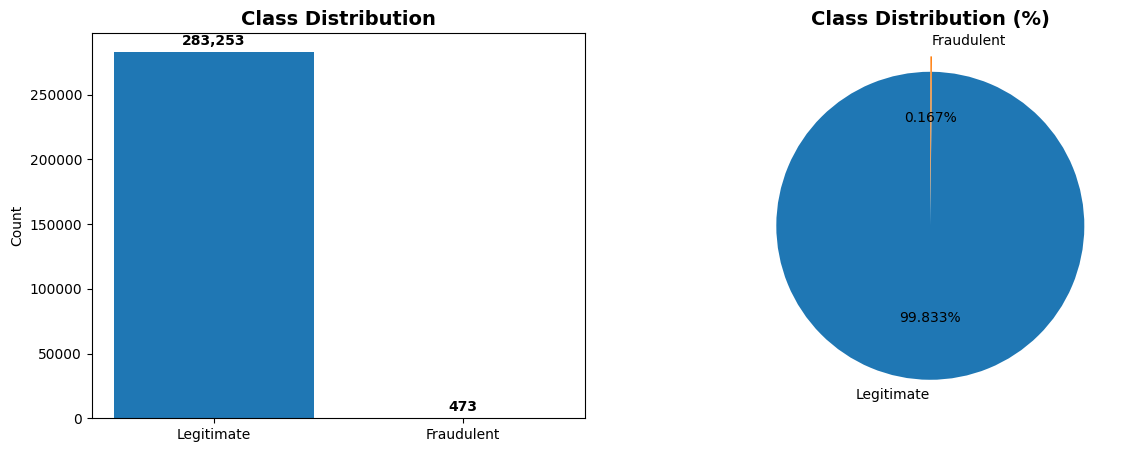

In [8]:
# Class Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
class_counts = fraud_df['Class'].value_counts()

axes[0].bar(['Legitimate', 'Fraudulent'], class_counts.values)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, count in enumerate(class_counts.values):
    axes[0].text(i, count + 5000, f'{count:,}', ha='center', fontweight='bold')

#Pie chart for class imbalance
class_counts = fraud_df['Class'].value_counts()
plt.pie(class_counts.values, labels=['Legitimate', 'Fraudulent'], autopct='%1.3f%%', explode=(0, 0.1), startangle=90)
plt.title('Class Distribution (%)', fontsize=14, fontweight='bold')

In the meantime, we store in the two variables below the amount of fraudulent (positive) and legitimate (negative) records, as we will need them later, and in the meantime we also define fraud_df_fraud and fraud_df_legit to store the data for fraudulent and legitimate transactions. We also store the amount of time this dataset comprises, it will be useful later to estimate the overall business impact

In [9]:
fraud_df_fraud = fraud_df[fraud_df['Class']==1]
fraud_df_legit = fraud_df[fraud_df['Class']==0]

total_negative_examples = fraud_df_legit.shape[0]
total_positive_examples = fraud_df_fraud.shape[0]
probability_positive = total_positive_examples/(total_positive_examples + total_negative_examples) # denominator is equivalent to fraud_df.shape[0]

total_number_of_days = fraud_df['Time'].max()/(24*3600)

## 2) Exploratory data analysis

We will investigate the distribution of the features separately for the genuine and fraudulent transactions to understand which ones can help us detect fraudulent transactions

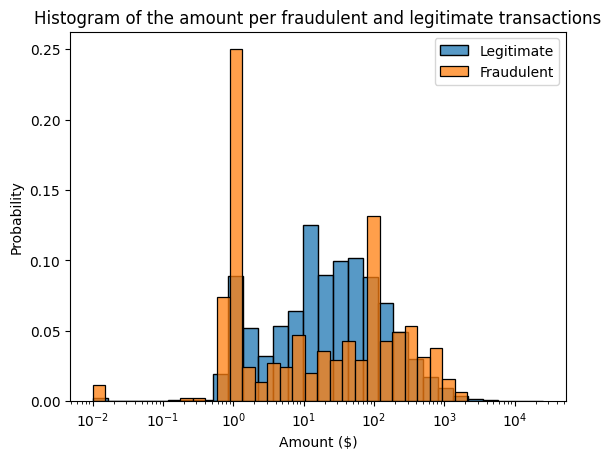

In [10]:
#Amount for legitimate and fraudulent transactions
sns.histplot(data=fraud_df_legit, x="Amount", log_scale=True, bins=30, stat="probability", label="Legitimate")
sns.histplot(data=fraud_df_fraud, x="Amount", log_scale=True, bins=30, stat="probability", label="Fraudulent")
plt.xlabel("Amount ($)")
plt.title("Histogram of the amount per fraudulent and legitimate transactions")
plt.legend()

It looks like the amount distribution for fraudulent transactions is broader than the one for legit ones, and there appears to be a peak at around 1 $, but the distributions also overlap. At the moment, the amount might still carry significant information about the nature of the transaction, but this will be established in the training part of this notebook (feature importances). Regarding the overall shapes, it seems that a log transformation can bring the amount variable closer to a Gaussian (or at least bell-shaped) distribution, so this is one transformation we will use in data preprocessing (more sophicasted methods will not be investigated here).

We store in a separate variable the mean amount per fraudulent transaction. This will be needed to optimize the threshold for the model chosen to identify fraudulent transactions, taking into account the false positives and negative

In [11]:
mean_fraud_amount = fraud_df_fraud['Amount'].mean()
print(f"Mean amount for fraudulent transactions is: {mean_fraud_amount:.4f} $")

Mean amount for fraudulent transactions is: 123.8719 $


Let's now look at the time distributions of these transactions. In particular, it might be useful to see if transactions occur at certain hours of the day.

Text(0.5, 1.0, 'Transaction probability as a function of the hour of the day')

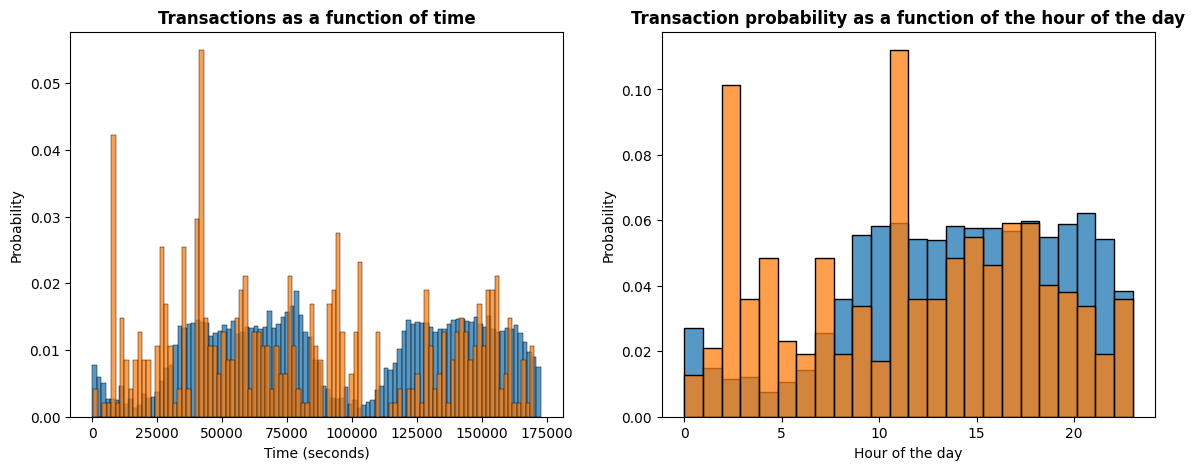

In [12]:
# Time Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time distribution
sns.histplot(data=fraud_df_legit, x="Time", bins=100, stat="probability", ax=axes[0])
sns.histplot(data=fraud_df_fraud, x="Time", bins=100, stat="probability", ax=axes[0])
axes[0].set_title('Transactions as a function of time', fontweight='bold')
axes[0].set_xlabel('Time (seconds)')


# Transactions vs hour of the day
fraud_df_fraud['Hour'] = (fraud_df_fraud['Time'] // 3600) % 24 #the code in parenthesis performs the integer division to convert from seconds to hours, the second is to extract the rest of the division by 24 (to introduce the 24-hour periodicity)
fraud_df_legit['Hour'] = (fraud_df_legit['Time'] // 3600) % 24
sns.histplot(data=fraud_df_legit, x="Hour", bins=24, stat="probability", ax=axes[1])
sns.histplot(data=fraud_df_fraud, x="Hour", bins=24, stat="probability", ax=axes[1])
axes[1].set_xlabel("Hour of the day")
axes[1].set_title("Transaction probability as a function of the hour of the day", fontweight='bold')

In the figure on the left, we see a seasonal trend, potentially due to the hour of day, and we also see differences between the legitimate and fraudulent transactions, the latter seem to be more prominent in the "holes". The might be difference between the first a second day for the fraudulent transactions, but the might also be due to statistical fluctuations, given that the number of fraudulent records is very low. It appears that we have more fraudulent transactions from hour 1-5 and then a spike at around 11. A reminder, this is the hour with respect to the first transaction: to understand the part of the day to which they refer we should know when the first transaction happened. Apart from this, this variable might still carry some information, but there is also a large overlap between the two distributions. From feature importances we will be able to tell if this variable carries significant information.

Continuing the exploratory data analysis, for the investigation of the relationship between the V* features and the target, we will use the correlation matrix and only inspect more thoroughly the features with an absolute correlation greater than 0.1 (determined as a tradeoff between the correlation and the amount of features that are correlated with the target)

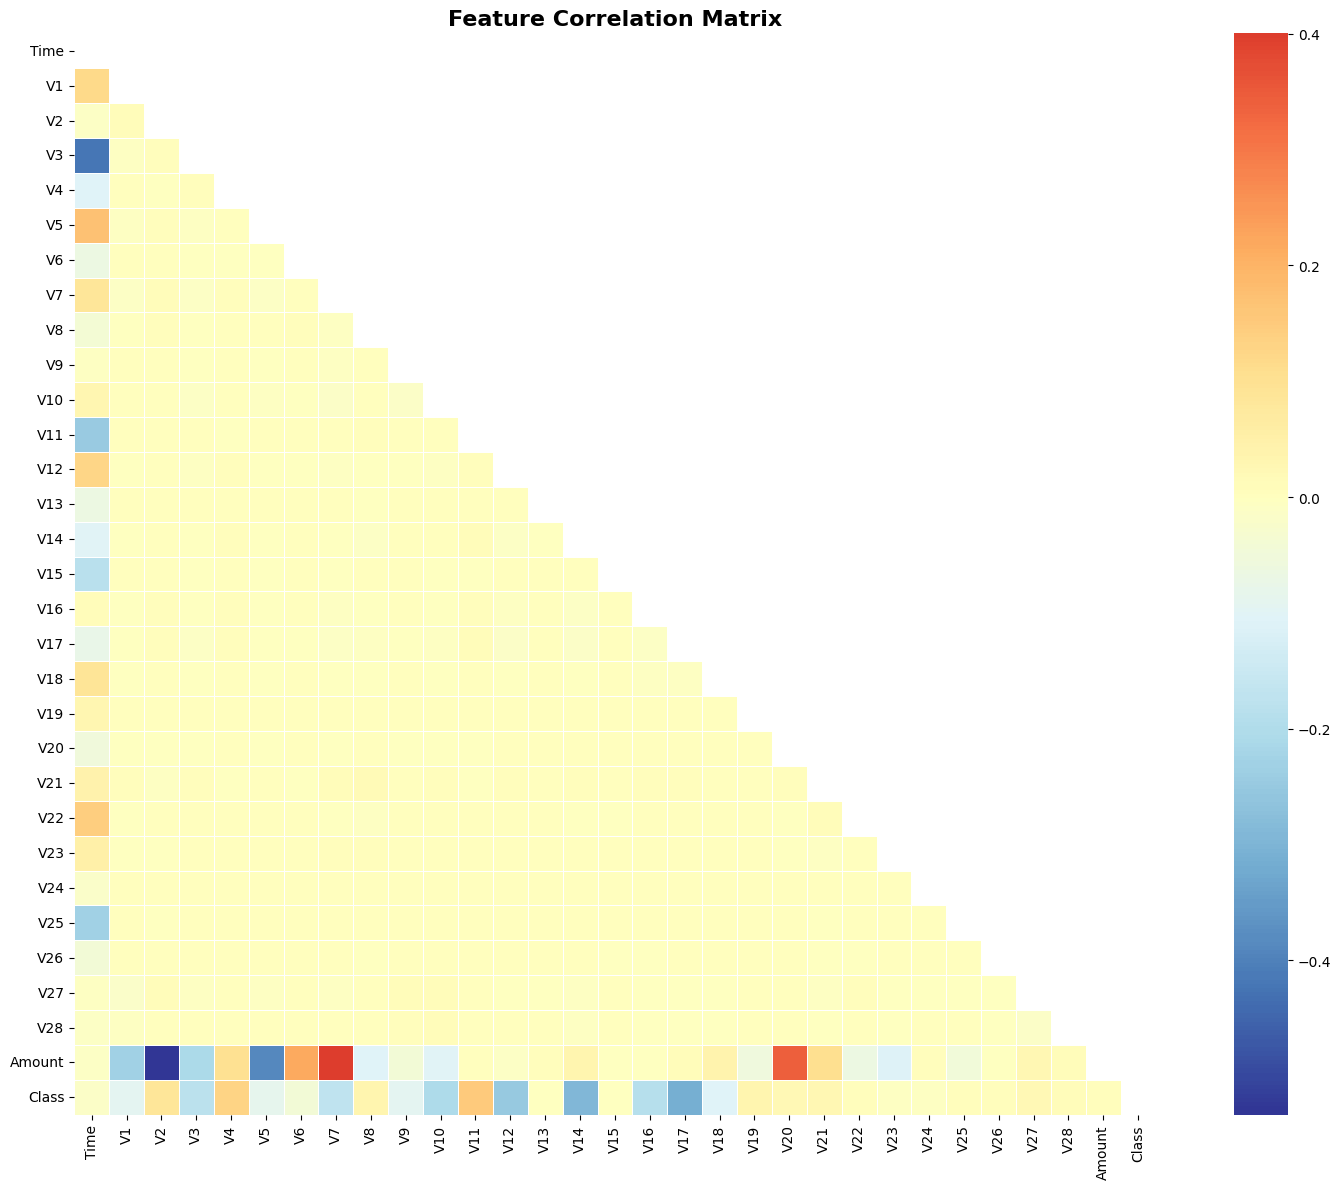

In [13]:
# Correlation Analysis
fig, ax = plt.subplots(figsize=(16, 12))

corr = fraud_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, center=0, cmap='RdYlBu_r', square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

We can see that all the features (we are not taking into account the class column) have a correlation coefficient smaller than 0.6 in absolute value, excluding a possible strong correlation between them. This will be important in the context of feature selection, as we do not need to take into account multicollinearity for the baseline approach.

Let's proceed to explore the V* columns further

In [14]:
top_v_features = []
v_features = [column for column in fraud_df.columns if "V" in column]
for feature in v_features:
    if abs(fraud_df.corr().loc["Class",feature])>0.1:
        top_v_features.append(feature)

print(top_v_features)

['V3', 'V4', 'V7', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18']


Let's explore how these features change for legitimate and fraudulent transactions

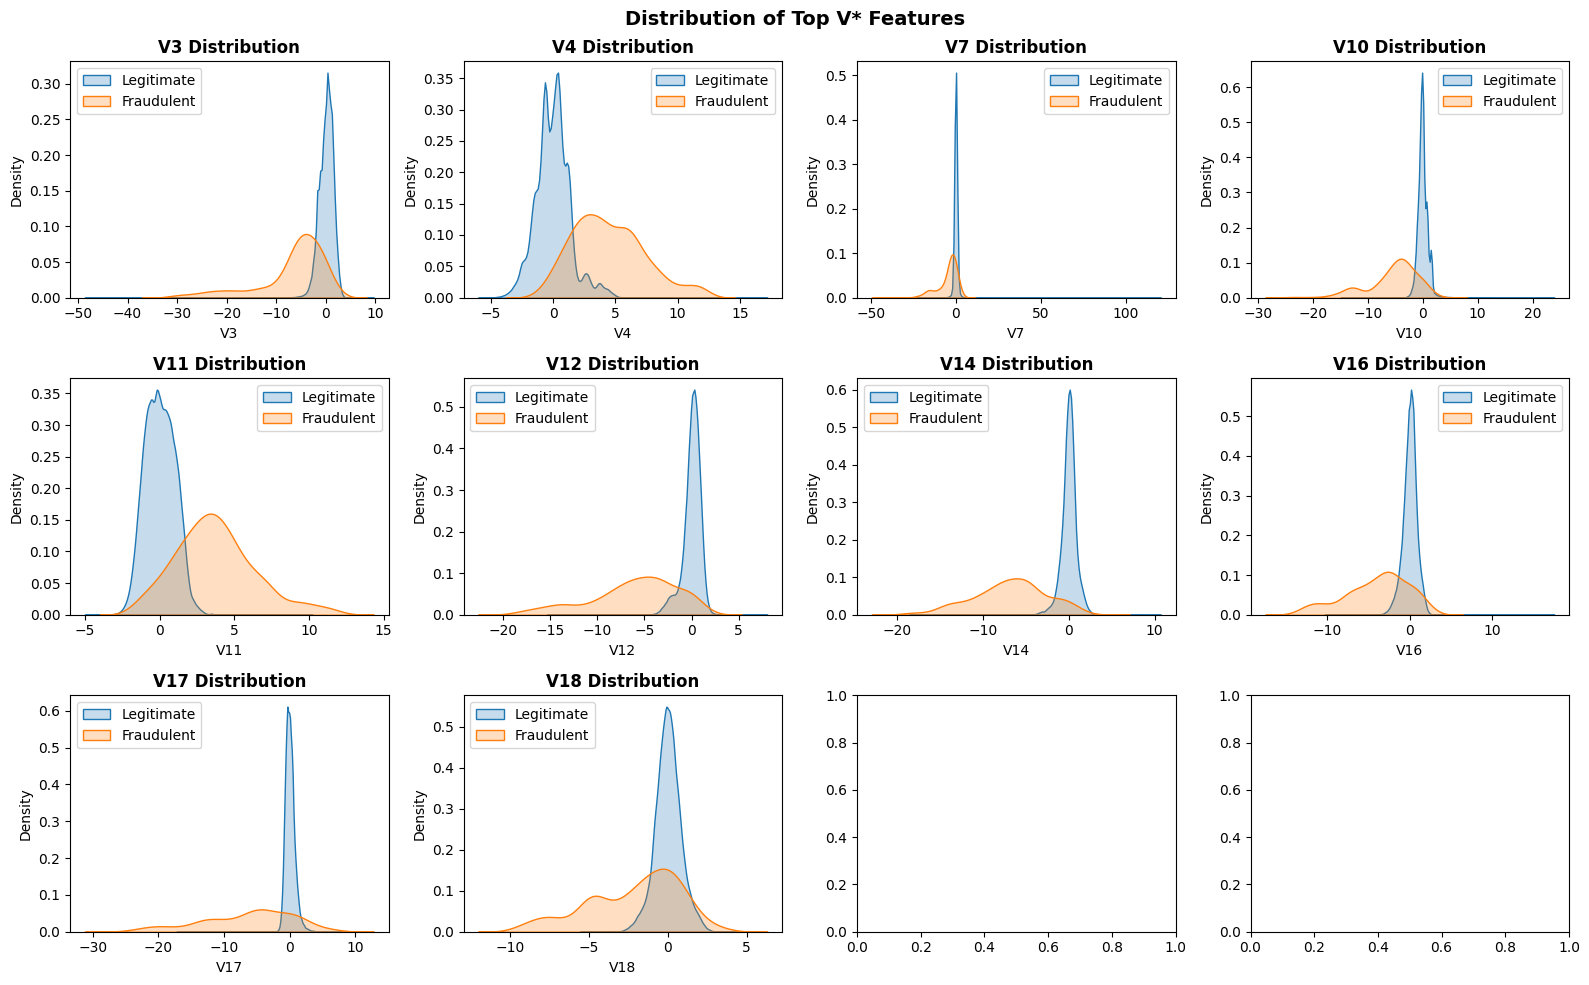

In [15]:
number_of_plots = len(top_v_features)
cols = math.ceil(math.sqrt(number_of_plots))
rows = math.ceil(number_of_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 10))
axes = axes.flatten()

for index, feature in enumerate(top_v_features):
    sns.kdeplot(data=fraud_df_legit, x=feature, ax=axes[index], label='Legitimate', fill=True)
    sns.kdeplot(data=fraud_df_fraud, x=feature, ax=axes[index], label='Fraudulent', fill=True)
    axes[index].set_title(f'{feature} Distribution', fontweight='bold')
    axes[index].legend()

plt.suptitle('Distribution of Top V* Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

It seems like these distributions differ significantly for legitimate and fraudulent transactions, and they might actually carry the necessary information about the target. For the majority class, they are also fairly bell-shaped, while for the fraud class they differ quite significantly, with extreme values that are very different. A simple standard scaling should already take everything into account, as extreme values are not outliers in this case.

## 3) Data preprocessing

In [16]:
#Introduce 24 hour periodicity in fraud_df["Time"]
hour = (fraud_df['Time'] // 3600) % 24 # we take only the integer part, we take the rest of the integer division by 24 to define the hour
fraud_df['Time_sin'] = np.sin(2 * np.pi * hour / 24)
fraud_df['Time_cos'] = np.cos(2 * np.pi * hour / 24)
fraud_df = fraud_df.drop('Time', axis=1)

#Use logarithm of amount, ad we have seen that it returns fairly bell-shaped distributions
fraud_df['Log_Amount'] = np.log(0.001+fraud_df['Amount']) #0.001 is added to avoid computing logarithm of 0
fraud_df = fraud_df.drop('Amount', axis=1)

Let's now divide fraud_df into a training/cross-validation part and a testing part. The first part will be used to determine the machine learning model to predict fraudulent transactions, while the second part will be used to select the score threshold that minimizes the cost due to both the false positives and negatives

In [17]:
# Creating a dataframe with TEST_SIZE values of original dataframe, which will be used in the final validation

X_for_split = fraud_df.drop(columns=['Class'])
y_for_split = fraud_df['Class']

X_for_split_train, X_for_split_test, y_for_split_train, y_for_split_test = train_test_split(X_for_split, y_for_split, random_state=RANDOM_STATE, test_size=TEST_SIZE, stratify=y_for_split)

fraud_df_train = pd.DataFrame(data = X_for_split_train, columns = fraud_df.columns)
fraud_df_train['Class'] = y_for_split_train
fraud_df_test = pd.DataFrame(data = X_for_split_test, columns = fraud_df.columns)
fraud_df_test['Class'] = y_for_split_test

## 4) Supervised fraud detection model building

In these subsections we actually develop the models to identify the separate the fraudulent transactions from the legitimate ones. As of this version of the notebook, we only explore supervised approaches, which require us to label fraudulent activities, while in reality this is not necessarily possible and one would have to develop an approach based on anomaly detection (using for example isolation forests). We explore two models: a baseline using logistic regression, and a more complicated one using gradient boosted decision trees. For both approaches, we first consider only a subset on the V* features, the top ones defined above, and then check the impact of including the rest of the features. We won't explore more sophisticated approaches, such as Lasso Regression for feature selection, or iterative approaches (where features are either added or subtracted recursively, and the impact on one selected score is checked), to keep the notebook relative short, while still exploring a few options. We also give a trivial example of hyperparameter tuning.

For each approach, we define k-folds using StratifiedKFold with four folds and we run training k times. Each time, we consider k-1 folds for training and 1 fold for testing. We compute the costs per transaction for each fold using the fold used for testing, and we print the mean and standard deviation of the cost at the minimum for each fold, as this is the quantity that we wish to minimize. To handle class imbalance, we use class_weight="balance" for logistic regression and scale_pos_weight for xgb. We could try other approaches in future versions of this project, for example resampling using SMOTE, but at the moment these were not considered due to the strong overfitting the might introduce in the sampling of the new records.

**Note**: in a previous version of this project the model was first chosen by looking at the ROC AUC, and then the threshold was optimized separately based on the cost. This has two issues: first, ROC AUC is not reliable for highly umbalanced data. This could be fixed by using Precision-Recall AUC, which brings to the second issue: this metric is evaluated all over the values of precision and recall, which is ideal when one wants to find the model which best separates the transactions as a whole, but is less ideal when the economic impact of the precision and recall must be taken into account (for example, we might find that the working point that minimizes cost is not necessarily one that has a particularly high precision, recall, or both, due to the class imbalance and the cost of misclassifying each class).

### Definition of the cost per transaction
When a fraudulent transaction occurs, it results in a loss of revenue corresponding to the amount of the transaction itself. This would call for action to investigate and potentially suspicious transactions. At the same time, investigating a transaction has a cost, which can reach up to 10\$, see for example ([here](https://www.mastercard.com/us/en/news-and-trends/Insights/2025/what-s-the-true-cost-of-a-chargeback-in-2025.html)), we will assume 5\$ in this project. If this cost is spent on blocking a legitimate transaction, it causes a waste in resources and consequent loss in revenue. Therefore, we need a tradeoff between flagging as many fraudulent transactions as possibile, increasing the amount of false positives and the total cost of action for these cases, and reducing the total cost due to the interventions, which might increase the amount of false negatives and a consequent loss in revenue. For a given classifier threshold, which results in a given false positive and a false negative rate, the difference in costs due to missing fraudulent transactions and inspecting legitimate transactions is:

$Cost = \textrm{Number of False Positives(Threshold)} * \textrm{Cost of intervention} + \textrm{Number of False Negatives(Threshold)} * \textrm{Avg fraud}$

Where Avg fraud is the average amount per fraudulent transaction (which we stored earlier). This can also be written as:

$Cost = \textrm{Number of legitimate transactions} * \textrm{False positive rate} * \textrm{Cost of intervention} + \textrm{Number of fraudulent transactions} * \textrm{False negative rate} * \textrm{Avg fraud}$

In the actual minimization of this quantity, it turns out that the actual overall amount of transactions doesn't affect the minimum, and we only need the imbalance between the fraudulent and the legitimate transactions:

$NormCost = P(legitimate) * \textrm{False positive rate} * \textrm{Cost of intervention} + P(fraudulent) * \textrm{False negative rate} * \textrm{Avg fraud}$

where P(legitimate) = 1- P(fraudulent) and P(fraudulent) can be computed as:

$ P(fraudulent) = \frac{\textrm{Total number of fraudulent transactions in fraud\_df}}{\textrm{fraud\_df.shape[0]}}$

With this in mind, we scan to find the minimum normcost value as a function of the score threshold. Here, we use the thresholds derived from the roc_curve function, and we derive the false negative rate as 1-true positive rate

The selection of the model and the threshold is done on the basis of the minimum per-transaction cost and its standard deviation, as derived from the k-fold validation of the test sample. Regarding the training samples for each fold, these are split in a dataset used only to train the model, and a part used only to select the threshold that minimizes the cost, this model and threshold are then used to compute the cost on the residual dataset.

**Note on Cost Assumptions**:
The $5 per transaction represents the estimated cost of investigating fraudulent transactions, based on industry averages. This is not the full cost of fraud prevention, as it does not account for potential indirect costs such as:

* Transaction Blocking: When transactions are flagged as fraudulent or blocked automatically, there may be customer churn if customers feel their transactions were unjustly blocked, which could lead to lost revenue and customer lifetime value (CLV).

* Customer Support and Reputational Impact: Fraud cases may also require additional customer support or could harm the business’s reputation, potentially leading to further revenue loss.

In this analysis, the $5 is used as a simplified estimate of investigation costs only, and additional costs like those mentioned above would increase the total cost of fraud detection.

### 4.1) First attempt using selected V* features

As a first approach, we use only the top_v_features investigate more in detail above

In [18]:
#we select only the top v* features, time and log_amount
fraud_df_train_top = fraud_df_train[["Time_sin", "Time_cos", "Log_Amount", "Class",*top_v_features]]

In [19]:
kf = StratifiedKFold(n_splits=n_folds, random_state=RANDOM_STATE, shuffle=True)
#define logistic regression
log_reg_top = LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced")
#the line below performs the splitting in folds, training and testing, and scaling of the features
costs_log_reg_top, log_reg_top_models, scalers_log_reg_top, thresholds_log_reg_top = kfold_train_test_models(fraud_df_train_top, kf, log_reg_top, probability_positive, cost_per_false_positive, mean_fraud_amount)
print(f"Average per-transaction minimum cost = {sum(costs_log_reg_top)/len(costs_log_reg_top):3f}$")
print(f"Std = {np.sqrt(np.var(costs_log_reg_top)):3f}$")
print(f"Thresholds at minimum: {thresholds_log_reg_top}")

Average per-transaction minimum cost = 0.041107$
Std = 0.001704$
Thresholds at minimum: [np.float64(0.999932692606897), np.float64(0.9976536531294175), np.float64(0.9890958812438049), np.float64(0.9789771919355494)]


We get a cost at minimum of 0.0411 dollars with a standard deviation of 0.0017 dollars. It can be observed that the thresholds at the minimum are very close to one and change significantly across the different folds. This could be fixed by calibrating the probabilities, which should result in much more stable thresholds from one fold to the next. Let's order the columns used in the training by using the absolute value of the coefficients in logistic regression. In this and the following feature importances, it is always the first fold that will be used

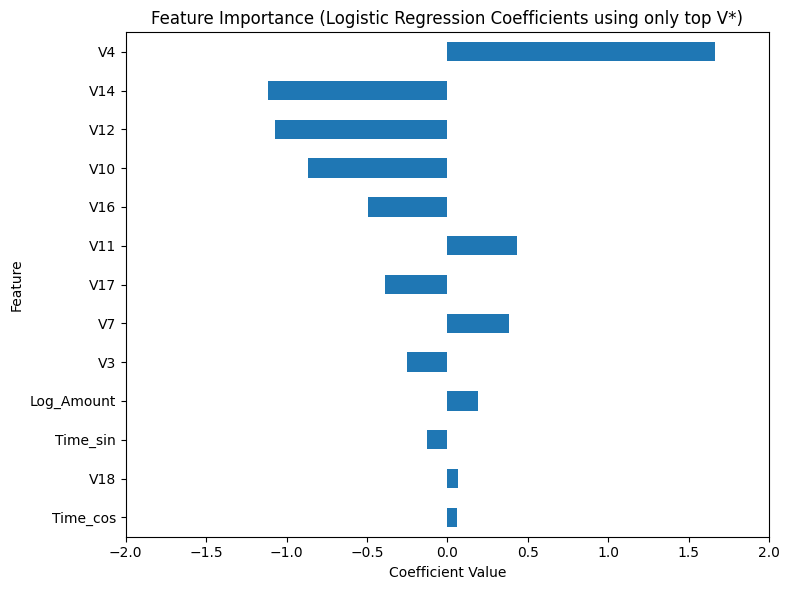

In [20]:
columns = [column for column in fraud_df_train_top.columns if column!="Class"]

coef_dict = dict(zip(columns, log_reg_top_models[0].coef_[0]))

sorted_coef = dict(sorted(coef_dict.items(), key=lambda x: -abs(x[1])))

# Convert dict to pandas Series
coef_series = pd.Series(sorted_coef)

# Plot
plt.figure(figsize=(8, 6))
coef_series.plot(kind='barh')

plt.title("Feature Importance (Logistic Regression Coefficients using only top V*)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.xlim(-2., 2.)

plt.gca().invert_yaxis()  # Most important on top
plt.tight_layout()
plt.show()

The V* feature have much large coefficients compared to Log_Amount and Time, meaning they provide most of the discriminating power between fraudulent and legitimate activities. Taking also this into account, we investigate the impact of including also the other V* in the predictions

### 4.2) Logistic regression with all features

In [21]:
kf = StratifiedKFold(n_splits=n_folds, random_state=RANDOM_STATE, shuffle=True)
log_reg = LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced")
costs_log_reg, log_reg_models, scalers_log_reg, thresholds_log_reg = kfold_train_test_models(fraud_df_train, kf, log_reg, probability_positive, cost_per_false_positive, mean_fraud_amount)
print(f"Average per-transaction minimum cost = {sum(costs_log_reg)/len(costs_log_reg):3f}$")
print(f"Std = {np.sqrt(np.var(costs_log_reg)):3f}$")
print(f"Thresholds at minimum: {thresholds_log_reg}")

Average per-transaction minimum cost = 0.040145$
Std = 0.004367$
Thresholds at minimum: [np.float64(0.999911143860229), np.float64(0.9994951094179982), np.float64(0.9958832879782702), np.float64(0.9917915756272848)]


The average cost is similar and its standard deviation is slightly lower. Once again, the thresholds at the minimum are very close to one and change significantly across different folds. If we print the logistic regression coefficients, we see that at least the first ones are larger in absolute value compared to before. V4 is still the most important feature, but notice the much different scale compared to the previous plot.

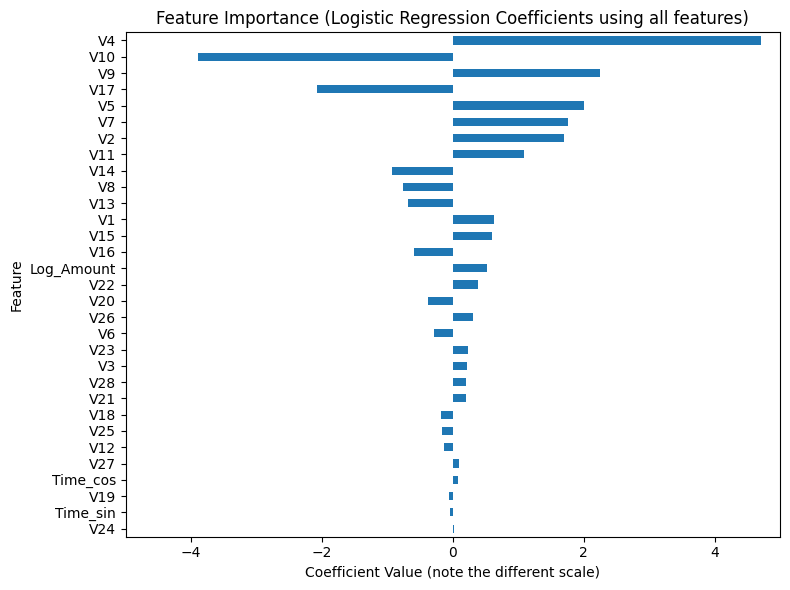

In [22]:
columns = [column for column in fraud_df_train.columns if column!="Class"]

coef_dict = dict(zip(columns, log_reg_models[0].coef_[0]))

sorted_coef = dict(sorted(coef_dict.items(), key=lambda x: -abs(x[1])))

# Convert dict to pandas Series
coef_series = pd.Series(sorted_coef)

# Plot
plt.figure(figsize=(8, 6))
coef_series.plot(kind='barh')

plt.title("Feature Importance (Logistic Regression Coefficients using all features)")
plt.xlabel("Coefficient Value (note the different scale)")
plt.ylabel("Feature")

plt.xlim(-5., 5.)

plt.gca().invert_yaxis()  # Most important on top
plt.tight_layout()
plt.show()

### 4.3) Gradient Boosted Decision Trees with top V* features

Let's now try to use XGBClassifier, initially only on the top V* features, then also on the others

In [23]:
kf = StratifiedKFold(n_splits=n_folds, random_state=RANDOM_STATE, shuffle=True)
xgboost_top = xgb.XGBClassifier(random_state=RANDOM_STATE, scale_pos_weight = total_negative_examples / total_positive_examples)
costs_xgb_top, xgboost_top_models, scalers_xgboost_top, thresholds_xgb_top = kfold_train_test_models(fraud_df_train_top, kf, xgboost_top,  probability_positive, cost_per_false_positive, mean_fraud_amount)
print(f"Average per-transaction minimum cost = {sum(costs_xgb_top)/len(costs_xgb_top):3f}$")
print(f"Std = {np.sqrt(np.var(costs_xgb_top)):3f}$")
print(f"Thresholds at minimum: {thresholds_xgb_top}")

Average per-transaction minimum cost = 0.036532$
Std = 0.000846$
Thresholds at minimum: [np.float64(0.1595122218132019), np.float64(0.1448696255683899), np.float64(0.03268079832196236), np.float64(0.03817397728562355)]


Text(0.5, 0, 'XGBoost Feature Importance (with only top V* features)')

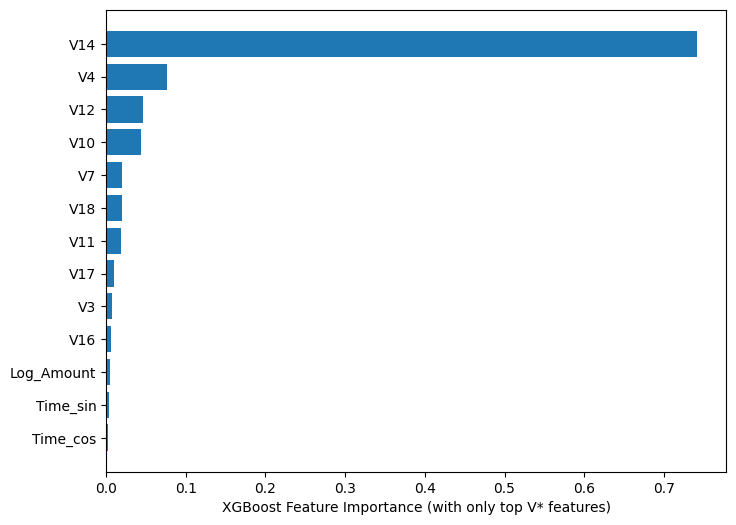

In [24]:
# plot feature importance
importances = xgboost_top_models[0].feature_importances_
unsorted_columns = [column for column in fraud_df_train_top.columns if column!="Class"]

sorted_idx = importances.argsort()
sorted_columns = [unsorted_columns[i] for i in sorted_idx]

plt.figure(figsize=(8, 6))
plt.barh(sorted_columns, importances[sorted_idx])
plt.xlabel("XGBoost Feature Importance (with only top V* features)")

The average cost is lower compared to when logistic regression with only the top V* features is used, and the standard deviation is lower too. For the importances, V* variable dominate, with in particular V14 dominating in this case. The threshold at the minimum changes even more across folds: this might be due to the predictions that are returned by the algorithm, which tend to be "overconfident" (either very close to 0 or to 1).

### 4.4) Gradient Boosted Decision Trees with all features

In [25]:
kf = StratifiedKFold(n_splits=n_folds, random_state=RANDOM_STATE, shuffle=True)
xgboost = xgb.XGBClassifier(random_state=RANDOM_STATE, scale_pos_weight = total_negative_examples / total_positive_examples)
costs_xgb, xgboost_models, scalers_xgboost, thresholds_xgb = kfold_train_test_models(fraud_df_train, kf, xgboost, probability_positive, cost_per_false_positive, mean_fraud_amount)
print(f"Average per-transaction minimum cost = {sum(costs_xgb)/len(costs_xgb):3f}$")
print(f"Std = {np.sqrt(np.var(costs_xgb)):3f}$")
print(f"Thresholds at minimum: {thresholds_xgb}")

Average per-transaction minimum cost = 0.034910$
Std = 0.001111$
Thresholds at minimum: [np.float64(0.3493192791938782), np.float64(0.01166382897645235), np.float64(0.04223022982478142), np.float64(0.05400871858000755)]


We see that the average cost is slightly lower than current best one (XGBoost only top V* features), and the standard deviation is slightly lower than in the best case, and once again the thresholds at the minimum change significantly. The feature importance plot below confirms what already found when only the top V* features where considered. However, since the thresholds changes much more dramatically compared to when only the top features are used, when considering the final model we use that version of XGB. This could be another reason to calibrate the probability distributions, to achieve more stable thresholds.

Text(0.5, 0, 'XGBoost Feature Importance (using all features)')

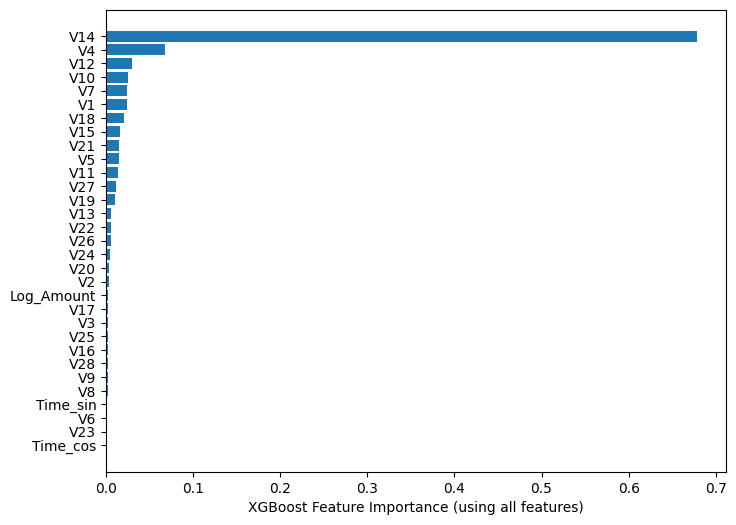

In [26]:
# plot feature importance
importances = xgboost_models[0].feature_importances_
unsorted_columns = [column for column in fraud_df_train.columns if column!="Class"]

sorted_idx = importances.argsort()
sorted_columns = [unsorted_columns[i] for i in sorted_idx]

plt.figure(figsize=(8, 6))
plt.barh(sorted_columns, importances[sorted_idx])
plt.xlabel("XGBoost Feature Importance (using all features)")

An attempt is made at seeing whether performance for XGB can be improved, resulting perhaps in a lower average minimum or a lower standard deviation, by changing the learning rate used in XGB (for the moment, only this parameter is considered).

In [27]:
learning_rate_xgb = [0.001, 0.01, 0.1, 0.3, 1, 3]
mean_minimum_cost = []
std_minimum_cost = []
costs_xgb_learning_rate = []
xgb_models_learning_rate = []
scalers_xgboost_learning_rate = []
thresholds_xgboost_learning_rate = []
for j in range(len(learning_rate_xgb)):
    xgboost = xgb.XGBClassifier(random_state=RANDOM_STATE, learning_rate=learning_rate_xgb[j], scale_pos_weight = total_negative_examples / total_positive_examples)
    costs, xgboost_models_rate, scalers_xgboost_rate, thresholds = kfold_train_test_models(fraud_df_train_top, kf, xgboost, probability_positive, cost_per_false_positive, mean_fraud_amount)
    mean_minimum_cost.append(sum(costs)/len(costs))
    std_minimum_cost.append(np.sqrt(np.var(costs)))
    xgb_models_learning_rate.append(xgboost_models_rate)
    scalers_xgboost_learning_rate.append(scalers_xgboost_rate)
    thresholds_xgboost_learning_rate.append(thresholds)

Text(0, 0.5, 'Mean minimum cost over folds')

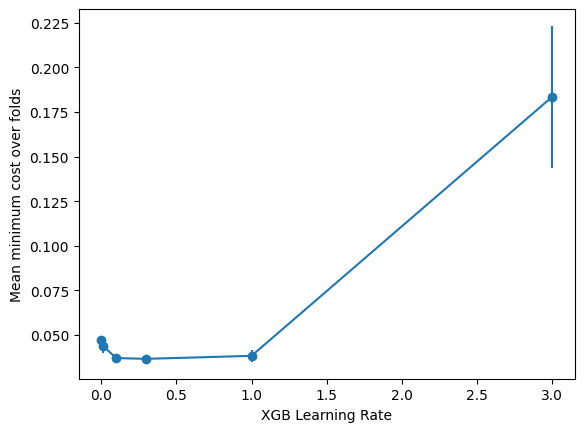

In [28]:
plt.errorbar(learning_rate_xgb, mean_minimum_cost, std_minimum_cost, marker='o')
plt.xlabel("XGB Learning Rate")
plt.ylabel("Mean minimum cost over folds")

There is a clear effect on the cost by changing the learning rate, with the minimum cost at 0.3. Let's inspect what are the cost and its standard deviation

In [29]:
print(f"Cost for learning rate equal to 0.3: mean {mean_minimum_cost[3]:3f}, std: {std_minimum_cost[3]:3f}")

Cost for learning rate equal to 0.3: mean 0.036532, std: 0.000846


We notice this is the same as the one we got before, meaning that the default learning rate was already 0.3

### 4.5) Final decision

From the results above, we can see that the costs at the minimum are slightly lower when XGB is considered. We use the configuration when only the top V* features are considered, as the thresholds at the minimum are lower.

We summarize here the choice of model and threshold, together with the cost at the minimum, and the true and false positive rates. For the actual final model, we retrain the chosen architecture taking all of the data used for training and validation in the k-fold procedure (the final test is performed on unseen data in the next session)

In [30]:
# final chosen model is:
final_features = [column for column in fraud_df_train_top.columns if column!="Class"]
final_threshold = np.mean(thresholds_xgb_top) # given how the threshold fluctuates across folds, we take the mean of the thresholds
index = 0
final_model = copy.deepcopy(xgboost_top_models[index]) # we choose one of the models randomly, we copy it, and we retrain it on all data used in the k-fold validation
final_scaler = copy.deepcopy(scalers_xgboost_top[index])
X_for_final_training = fraud_df_train[final_features]
y_for_final_training = fraud_df_train['Class']
final_scaler = final_scaler.fit(X_for_final_training)
X_for_final_training = final_scaler.transform(X_for_final_training)
final_model.fit(X_for_final_training, y_for_final_training)

print("Selected model: Logistic Regression (with all V* variables)")
print(f"Threshold corresponding to minimum normalized cost is {final_threshold:.4f}")
print("Strategy: minimize expected cost balancing fraud detection and false positives")

Selected model: Logistic Regression (with all V* variables)
Threshold corresponding to minimum normalized cost is 0.0938
Strategy: minimize expected cost balancing fraud detection and false positives


## 5) Test on unseen data

We estimate the true positive rate, the false positive rate, and the cost per transaction on previously unseen data in order to further validate the procedure, since this data was not used in training, validation or model selection.

In [31]:
X_fraud_test = fraud_df_test[final_features] # redefine interesting features for fraud_df_test
X_fraud_test_scaled = final_scaler.transform(X_fraud_test)
test_probabilities = final_model.predict_proba(X_fraud_test_scaled)[:, 1] # compute probabilities for unseen data
flagged_as_positive = test_probabilities >= final_threshold # use the final threshold to select which transactions are fraudulent
fraud_df_test_copy = fraud_df_test.copy() #to compute false and true positive rates without modifying the original dataframe
fraud_df_test_copy['flagged_as_positive'] = flagged_as_positive
fraud_df_test_positive = fraud_df_test_copy[fraud_df_test['Class']==True] # split the test dataset in the fraudulent and genuine transactions based on the observed label
fraud_df_test_negative = fraud_df_test_copy[fraud_df_test['Class']==False]
tpr_test = (fraud_df_test_positive['Class']==fraud_df_test_positive['flagged_as_positive']).sum()/fraud_df_test_positive.shape[0] #compute true and false positive rates by comparing the predicted values with the actual labels
fpr_test = (fraud_df_test_negative['Class']!=fraud_df_test_negative['flagged_as_positive']).sum()/fraud_df_test_negative.shape[0]

# compute cost at minimum on unseen data
cost_on_test_data = cost_per_false_positive*fpr_test*(1.-probability_positive)+mean_fraud_amount*(1.-tpr_test)*probability_positive

print(f"Per-transaction cost on test data is is {cost_on_test_data:.4f} $")
print(f"False positive rate at minimum: {fpr_test*100:.4f}%")
print(f"True positive rate at minimum: {tpr_test*100:.4f}%")

Per-transaction cost on test data is is 0.0409 $
False positive rate at minimum: 0.0330%
True positive rate at minimum: 80.9859%


The per-transaction is higher on the holdout sample, well outside the 1.96 sigmas from the minimum found before, so that this should not be treated as significant.

Large fold-to-fold fluctations in the thresolds can be observed, which is something that might be worth looking into. These fluctuations could be due to the sensitivity to small variations in the scores that might result in fraudulent transactions being flagged as genuine, or to the fact that, for this version of the project, the fraction of positives is assumed to be fixed, both in the cost function, but also when the training is performed (the total amounts of genuine and fraudulent events are used to weight the events in training, but this is assumed to be fixed, which might not necessarily be the case), so differences in the folds might induce fluctuations in the costs. Additionally, the probabilities are not calibrated, another element which might also help increase the discrimination performance.

### 5.2) Business implication

By multiplying the cost of false positives and false negatives per transaction by the total number of transactions in the dataset, and extrapolating from the two-day sample to a full year, the estimated total cost due to false positives and false negatives across all transactions in this dataset would be approximately:

In [32]:
yearly_cost = cost_on_test_data * fraud_df.shape[0] * 365 / total_number_of_days
print(f"The total yearly cost is {yearly_cost/1e6:.1f}M $")

The total yearly cost is 2.1M $


which is still a very large cost.

This estimation assumes the sample of transactions is representative of the typical yearly transaction volume for European cardholders, though it likely represents only a subset of all European cardholder transactions. At a larger scale—such as major financial institutions with significantly higher daily transaction volumes—this cost could grow substantially. For example, while this dataset covers just two days' worth of transactions, institutions processing millions of transactions daily could face even higher potential costs from false positives and false negatives.

This highlights that even well-performing models leave significant residual cost, due to the inherent trade-off between missed fraud and false positives.

## 6) Possible improvements
* Show model performance metrics (e.g. precision, recall)
* Consider unsupervised approach (e.g. isolation forest)
* Investigate further feature selection to find an optimal set of features
* Explore broader hyperparameter space to find better discrimination power (techniques might include GridSearchCV, LogisticRegressionCV)
* Check for difference between holdout sample and training sample, for example in the rates of fraudulent to genuine transactions (now this is assumed to be fixed for the whole dataset).
* Potentially investigate the possibility of calibrating the probabilities in order to improve the sensitivity and potentially reduce costs.
* Minimization is only in one variable, assumption is that all transactions and users can be treated in the same way. This is in general not true, so in principle this should become a multivariate minimization. This dataset doesn't allow it, the possibility of using another dataset can be studied. Also, in principle the rates can be a function of the cost, this has an impact on the minimization itself (from the analysis above, however, the amount per transaction doesn't seem to carry a lot of information about the nature of the transaction)
* Introduce comparison with baseline approach, not necessarily based on machine learning
* Investigate whether this can be turned into an approach ready for deployment

<h2>About the Author:</h2> 

Davide Bruschini has a PhD in Physics from Scuola Normale Superiore, and he has been part of the CMS collaboration at CERN since 2020. Davide Bruschini is now looking for employment in industry.